In [1]:
import sys, os
while not os.path.isdir('src') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')
sys.path.insert(0, 'src')
import numpy as np, json
import matplotlib.pyplot as plt
os.makedirs('dashboard/data', exist_ok=True)
from tradinglab.data_feed import DataFeed
from tradinglab.features import build_pooled_dataset

EPOCHS = 150
COMMISSION = 0.00
TOP_K = 4
SEQ_LEN = 10

feed = DataFeed.from_dir('data/egx')
# feed = DataFeed.from_dir('data/egx', symbols=['COMI', 'HRHO', 'TMGH', 'SWDY', 'FWRY', 'ABUK'])
# feed = DataFeed.from_dir('data/egx', symbols=['ABUK'])

split_day = int(feed.n_days * 0.7)
X_train, y_train, X_test, y_test = build_pooled_dataset(feed, split_day)
n_features = X_train.shape[1]
print('same dataset as yesterday:', len(X_train), 'train /', len(X_test), 'test')


d:\EFG\2026-orion\src\tradinglab\features.py:64: RuntimeWarning: invalid value encountered in divide
  volume_ratio = volume / vol_avg20


same dataset as yesterday: 26588 train / 11798 test


In [2]:
def to_sequences(X, y, seq_len=5):
    xs, ys = [], []
    # ---8<--- solution
    for i in range(seq_len, len(X)):
        xs.append(X[i-seq_len:i]); ys.append(y[i])
    # ---8<--- end
    return np.array(xs, dtype='float32'), np.array(ys, dtype='float32')

from tradinglab.features import build_pooled_sequences

Xtr_s, ytr_s, Xte_s, yte_s = build_pooled_sequences(feed, split_day, seq_len=SEQ_LEN)
# assert Xtr_s.shape[1:] == (5, n_features), 'wrong sequence shape'
# print('to_sequences correct ✓  ->', Xtr_s.shape)


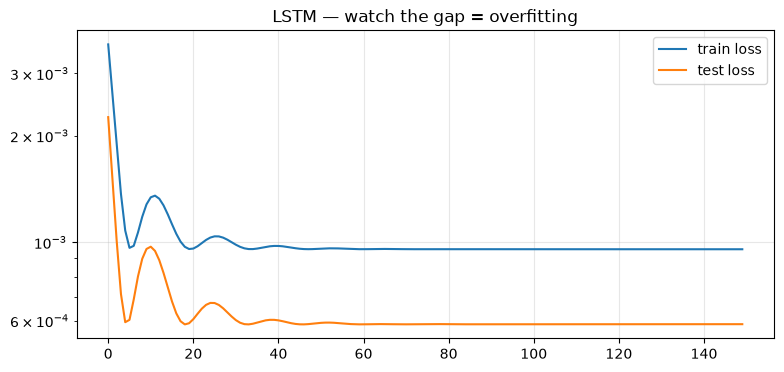

final train 0.00096 | test 0.00059


In [3]:
import torch; torch.manual_seed(0)
from tradinglab.models import LSTMRegressor
from tradinglab.ml import train_model, predict

lstm = LSTMRegressor(n_features=n_features, hidden=32)
history = train_model(lstm, Xtr_s, ytr_s, Xte_s, yte_s, epochs=EPOCHS)

plt.figure(figsize=(9,4))
plt.plot(history['train'], label='train loss'); plt.plot(history['test'], label='test loss')
plt.yscale('log')
plt.legend(); plt.grid(alpha=.3); plt.title('LSTM — watch the gap = overfitting'); plt.show()
print('final train %.5f | test %.5f' % (history['train'][-1], history['test'][-1]))


In [ ]:
def lstm_to_strategy(model, seq_len, top_k=2):
    from tradinglab.strategies.predictor import predictions_to_weights
    def strategy(observation):
        window = observation[:, -seq_len:, :]              # take only the last seq_len days
        preds = predict(model, window.astype('float32'))
        return predictions_to_weights(preds, top_k)
    return strategy


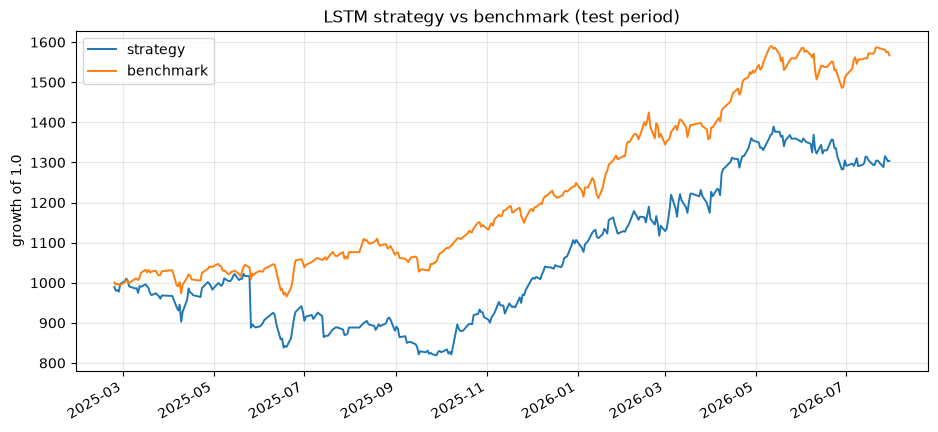

total return   : +30.4%
sharpe         : 0.90
max drawdown   : 19.9%
final value    : 1303.91   (benchmark 1567.20)
beat benchmark : no
                 you lost to the benchmark by 263 EGP
Saved LSTM dashboard results to: dashboard/data/lstm_results.json


In [7]:
from tradinglab.simulator import PortfolioSimulator
from tradinglab.backtester import run_backtest
from tradinglab.report import report
from tradinglab.strategies.predictor import model_to_strategy
from tradinglab.models import MLP

sim = PortfolioSimulator(feed)
split = int(feed.n_days * 0.7)

result_lstm = run_backtest(sim, lstm_to_strategy(lstm, seq_len=SEQ_LEN, top_k=TOP_K), lookback=30, start=split)
report(result_lstm, title='LSTM strategy vs benchmark (test period)', start_capital=1000.0)

# ============================================================
# SAVE LSTM + MLP RESULTS FOR DASHBOARD
# ============================================================

START = 1000.0

dates = [str(x) for x in result_lstm["dates"]]

lstm_portfolio = result_lstm["portfolio"].tolist()
mlp_portfolio = result_mlp["portfolio"].tolist()
benchmark_portfolio = result_lstm["benchmark"].tolist()

dashboard_results = {
    "status": "ok",

    "model": {
        "name": "LSTM",
        "sequence_length": SEQ_LEN,
        "top_k": TOP_K,
        "epochs": EPOCHS
    },

    "loss": {
        "train": [
            float(x)
            for x in history["train"]
        ],

        "test": [
            float(x)
            for x in history["test"]
        ]
    },

    "dates": dates,

    "equity": {
        "lstm": [
            round(float(x) * START, 4)
            for x in lstm_portfolio
        ],

        "mlp": [
            round(float(x) * START, 4)
            for x in mlp_portfolio
        ],

        "benchmark": [
            round(float(x) * START, 4)
            for x in benchmark_portfolio
        ]
    },

    "final_values": {
        "lstm": round(
            float(lstm_portfolio[-1]) * START,
            4
        ),

        "mlp": round(
            float(mlp_portfolio[-1]) * START,
            4
        ),

        "benchmark": round(
            float(benchmark_portfolio[-1]) * START,
            4
        )
    }
}

with open(
    "dashboard/data/lstm_results.json",
    "w"
) as f:

    json.dump(
        dashboard_results,
        f,
        indent=2
    )

print(
    "Saved LSTM dashboard results to:"
    " dashboard/data/lstm_results.json"
)

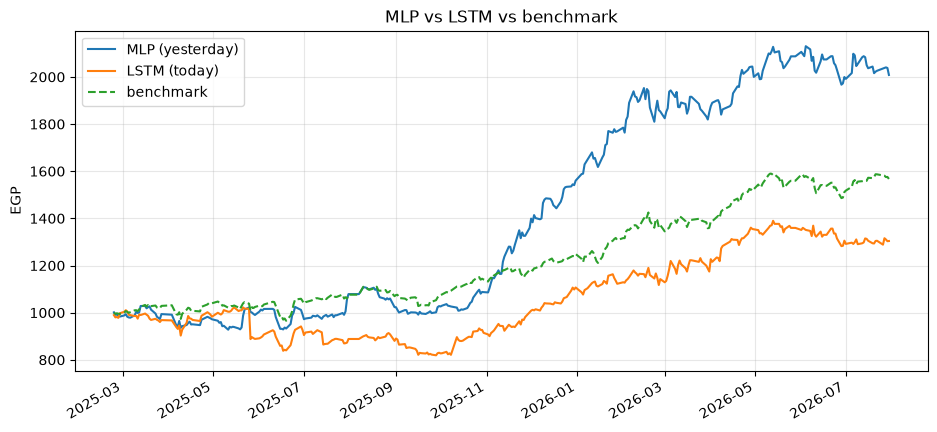

MLP final : 2,008 EGP
LSTM final: 1,304 EGP
benchmark : 1,567 EGP


In [6]:
mlp = MLP(n_features, hidden=32)
train_model(mlp, X_train, y_train, X_test, y_test, epochs=1500)
result_mlp = run_backtest(sim, model_to_strategy(mlp, top_k=TOP_K), lookback=30, start=split)

START = 1000.0
dates = result_lstm['dates']
plt.figure(figsize=(11,5))
plt.plot(dates, result_mlp['portfolio']*START, label='MLP (yesterday)')
plt.plot(dates, result_lstm['portfolio']*START, label='LSTM (today)')
plt.plot(dates, result_lstm['benchmark']*START, label='benchmark', linestyle='--')
plt.legend(); plt.grid(alpha=.3); plt.ylabel('EGP'); plt.title('MLP vs LSTM vs benchmark')
plt.gcf().autofmt_xdate(); plt.show()

print(f"MLP final : {result_mlp['portfolio'][-1]*START:,.0f} EGP")
print(f"LSTM final: {result_lstm['portfolio'][-1]*START:,.0f} EGP")
print(f"benchmark : {result_lstm['benchmark'][-1]*START:,.0f} EGP")
